# MSc mammography denoising - historical experiment
Muhammad Ahsan Ateeq | University of Hull

**Archive, not a runnable entry point.** Outputs below came from the submitted notebook; they were not recomputed. Local paths and student identifiers were removed, training logs trimmed, and mammogram image outputs omitted. Original code defects are retained for traceability. Use `reproduce.ipynb` or the Python modules for the new workflow. See `../docs/methodology.md`.


# Relevant Libraries

In [28]:
# Importing operating system functionality
import os

# Importing numerical computation library
import numpy as np

# Importing computer vision library
import cv2

# Importing machine learning library
import tensorflow as tf
import keras 

# Importing plotting library
import matplotlib.pyplot as plt

# Importing image preprocessing functions from TensorFlow and Keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.image import load_img, img_to_array

# Importing image quality metrics from scikit-image
from skimage.metrics import peak_signal_noise_ratio, mean_squared_error,structural_similarity
from skimage import io, color

# Importing layers and Model from TensorFlow Keras
from tensorflow.keras import layers, Model

# Importing utility functions for handling data sequences from Keras
from keras.utils import Sequence

# Importing file path matching functionality
import glob

# Importing ModelCheckpoint callback from Keras
from keras.callbacks import ModelCheckpoint

# Importing model loading function from TensorFlow Keras
from tensorflow.keras.models import load_model

# Useful Functions 

In [25]:
# Define the path to your dataset
#dataset_path = "data/breast cancer"

def preprocess(images):
    processed_images = []
    for image_filename in images:
        # Load the image
        image_path = os.path.join(dataset_path, image_filename)
        img = load_img(image_path, color_mode="grayscale", target_size=(256,256))

        # Convert the image to a NumPy array and normalize
        img_array = img_to_array(img)
        img_array = img_array.astype("float32") / 255.0
        processed_images.append(img_array)
    
    return np.array(processed_images)

def noise(array):
    """
    Adds random noise to each image in the supplied array.
    """

    noise_factor = 0.4
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0
    )

    return np.clip(noisy_array, 0.0, 1.0)


def add_noise_and_save_preprocessed(images, output_path, noise_factor=0.4):
    """
    Add random noise to preprocessed images and save the noisy images.

    Parameters:
    - preprocessed_images: List of preprocessed images (NumPy arrays).
    - output_path: Path to the directory where noisy images will be saved.
    - noise_factor: Factor controlling the intensity of the noise.

    Returns:
    None
    """
    noisy_images = []
    # Create output directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    i=0
    for image_filename in images:
        
        image_path = os.path.join(dataset_path, image_filename)
        img = load_img(image_path, color_mode="grayscale", target_size=(512, 512))

        # Convert the image to a NumPy array and normalize
        img = img_to_array(img)
        #img = img.astype("float32") / 255.0
       
        # Add random noise
        noise = np.random.normal(loc=0, scale=noise_factor * 255, size=img.shape)
        noisy_img = np.clip(img + noise, 0, 255).astype(np.uint8)
        #noisy_images.append((image_file, noisy_img))

        # Save the noisy image with a generic name (e.g., "noisy_image_0.jpg")
        #print(noisy_img.shape)
        #noisy_img=noise(img)
        output_image_path = os.path.join(output_path, image_filename)
        cv2.imwrite(output_image_path, noisy_img)
        i+=1

    return noisy_images


def display(array1, array2):
    """
    Displays ten random images from each one of the supplied arrays.
    """
    n = 5

    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]
    

    plt.figure(figsize=(60, 20))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1[:, :], cmap='gray')  # Adjust the reshape dimensions
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2[:, :], cmap='gray')  # Adjust the reshape dimensions
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        
    plt.show()

def display1(array1, array2,array3):
    """
    Displays ten random images from each one of the supplied arrays.
    """
    n = 5

    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]
    images3 = array3[indices, :]

    plt.figure(figsize=(60, 30))
    for i, (image1, image2,image3) in enumerate(zip(images1, images2, images3)):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(image1[:, :, 0], cmap='gray')  # Adjust the reshape dimensions
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(image2[:, :, 0], cmap='gray')  # Adjust the reshape dimensions
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(image3[:, :, 0], cmap='gray')  # Adjust the reshape dimensions
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)


    plt.show()    

# Data Pre-processing

In [3]:
dataset_path = "data/train_data"
all_images = os.listdir(dataset_path)

# Normalize and reshape the data
train_data = preprocess(all_images)

In [4]:
train_data.shape

(43776, 256, 256, 1)

In [5]:
dataset_path = "data/test_data"
all_images = os.listdir(dataset_path)

# Normalize and reshape the data
test_data = preprocess(all_images)

In [6]:
test_data.shape

(10930, 256, 256, 1)

In [ ]:
# Create a copy of the data with added noise
noisy_train_data = add_noise_and_save_preprocessed(train_data)
noisy_test_data = add_noise_and_save_preprocessed(test_data)

In [26]:
dataset_path = "data/noisy_train_data"
all_images = os.listdir(dataset_path)

# Normalize and reshape the data
noisy_train_data = preprocess(all_images)

In [27]:
noisy_train_data.shape

(43776, 256, 256, 1)

In [7]:
dataset_path = "data/noisy_test_data"
all_images = os.listdir(dataset_path)

# Normalize and reshape the data
noisy_test_data = preprocess(all_images)

In [8]:
noisy_test_data.shape

(10930, 256, 256, 1)

# Convolutional De-noising Autoencoder Architecture

In [10]:
input_img = layers.Input(shape=(256,256, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
decoded_img = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Autoencoder
autoencoder = Model(input_img, decoded_img)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

# Custom Image Generator 

In [11]:
class CustomImageGenerator(Sequence):
    def __init__(self, image_paths, batch_size=128, image_size=(256,256), shuffle=True):
        self.image_paths = image_paths
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size
        batch_paths = self.image_paths[start_idx:end_idx]
        batch_images = [self.load_and_preprocess_image(image_path) for image_path in batch_paths]
        batch_images = np.array(batch_images)
        
        if "noisy_train_data" in self.image_paths[0]:
            batch_paths_noisy=[s.replace("noisy_train_data", "train_data") for s in batch_paths]
            
            batch_images_Input = [self.load_and_preprocess_image(image_path) for image_path in batch_paths_noisy]
            batch_images_Input = np.array(batch_images_Input)
        else:   
            batch_images_Input=batch_images

        return batch_images,batch_images_Input  # Assuming it's an autoencoder (input = output)
    
    def __iter__(self):
        # This method makes the generator an iterator
        for i in range(self.__len__()):
            yield self[i]
            
    def load_and_preprocess_image(self,image_path):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
        img = cv2.resize(img, self.image_size)
        img = img.astype('float32') / 255.0  # Normalize pixel values to [0, 1]
        return img
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.image_paths)


# Training of CDAE Model on Test Data without Noise

In [10]:
image_paths = glob.glob('data/train_data/*') 

# Create an instance of the custom generator
custom_generator = CustomImageGenerator(image_paths, batch_size=128, image_size=(256,256), shuffle=True)

custom_iterator = iter(custom_generator)

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint('autoencoder_test.h5', 
                             save_best_only=True, 
                             save_weights_only=False, 
                             period=10)

autoencoder.fit(
    custom_generator,
    epochs=50,
    batch_size=128,
    shuffle=True,
    callbacks=[checkpoint],
    validation_data=(test_data, test_data),
)

In [11]:
#Saving model 
autoencoder.save("data/autoencoder_test_model.h5")

# Prediction on Test data without Noise

In [12]:
predictions = autoencoder.predict(test_data)
display(test_data, predictions)

# Training of CDAE Model on Noisy Test data 

In [ ]:
noisy_paths = glob.glob('data/noisy_train_data/*') 

# Create an instance of the custom generator
noisy_data_custom_generator = CustomImageGenerator(noisy_paths, batch_size=128, image_size=(256,256), shuffle=True)

custom_iterator = iter(noisy_data_custom_generator)

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint('autoencoder_train_noisy_model.h5', 
                             save_best_only=True, 
                             save_weights_only=False, 
                             period=10)
from keras.models import load_model
autoencoder = load_model('data/autoencoder_train_model.h5')

autoencoder.fit(
    noisy_data_custom_generator,
    epochs=100,
    batch_size=128,
    shuffle=True,
    callbacks=[checkpoint],
)

In [21]:
autoencoder.save("data/autoencoder_train_model.h5")

In [12]:
predictions = autoencoder.predict(noisy_test_data)
display(noisy_test_data, predictions) 

## Test Data, Noisy Test Data and Prediction 

In [13]:
display1(test_data,noisy_test_data,predictions)

# Evaluation Metrics

## Peak Signal to Noise Ratio

In [14]:
psnr_value = peak_signal_noise_ratio(test_data,predictions)
psnr_value

18.831350149874776

## Mean Square Error 

In [15]:
mse = mean_squared_error(test_data, predictions)
mse

0.013087749832030362

# Min and Max value of PSNR and MSE

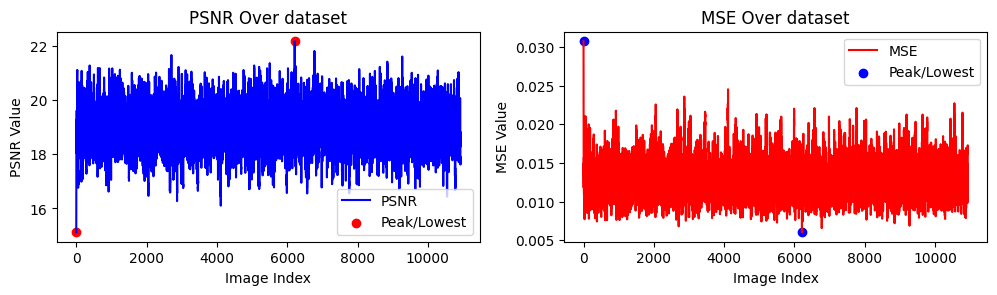

Peak PSNR: 22.18 dB at index 6212
Lowest PSNR: 15.12 dB at index 0
Peak MSE: 0.01 at index 6212
Lowest MSE: 0.03 at index 0


In [49]:
def calculate_metrics(original, degraded):
    psnr_value = peak_signal_noise_ratio(original, degraded)
    mse_value = mean_squared_error(original, degraded)
    return psnr_value, mse_value


num_samples = 10930
# Calculate metrics for each pair of images
psnr_values = []
mse_values = []
for i in range(num_samples):
    psnr, mse = calculate_metrics(test_data[i], predictions[i])
    psnr_values.append(psnr)
    mse_values.append(mse)

# Find peak and lowest values and their indices
peak_psnr_value = max(psnr_values)
lowest_psnr_value = min(psnr_values)
peak_psnr_index = psnr_values.index(peak_psnr_value)
lowest_psnr_index = psnr_values.index(lowest_psnr_value)

peak_mse_value = min(mse_values)  # Lower MSE is better
lowest_mse_value = max(mse_values)
peak_mse_index = mse_values.index(peak_mse_value)
lowest_mse_index = mse_values.index(lowest_mse_value)

# Plotting
plt.figure(figsize=(12, 6))

# PSNR Plot
plt.subplot(2, 2, 1)
plt.plot(psnr_values, label='PSNR', color='blue')
plt.scatter([peak_psnr_index, lowest_psnr_index], [peak_psnr_value, lowest_psnr_value], color='red', label='Peak/Lowest')
plt.title('PSNR Over dataset')
plt.xlabel('Image Index')
plt.ylabel('PSNR Value')
plt.legend()

# MSE Plot
plt.subplot(2, 2, 2)
plt.plot(mse_values, label='MSE', color='red')
plt.scatter([peak_mse_index, lowest_mse_index], [peak_mse_value, lowest_mse_value], color='blue', label='Peak/Lowest')
plt.title('MSE Over dataset')
plt.xlabel('Image Index')
plt.ylabel('MSE Value')
plt.legend()

plt.show()

# Print peak and lowest values and their indices
print(f"Peak PSNR: {peak_psnr_value:.2f} dB at index {peak_psnr_index}")
print(f"Lowest PSNR: {lowest_psnr_value:.2f} dB at index {lowest_psnr_index}")
print(f"Peak MSE: {peak_mse_value:.2f} at index {peak_mse_index}")
print(f"Lowest MSE: {lowest_mse_value:.2f} at index {lowest_mse_index}")


# calculating PSNR and MSE for Test data model without noise 

In [59]:
autoencoder_test = load_model("data/autoencoder_test_model.h5")

In [60]:
predictions_test2 = autoencoder_test.predict(test_data)
display(test_data, predictions_test2) 

# Peak Signal to Noise Ratio

In [61]:
psnr_value = peak_signal_noise_ratio(test_data,predictions_test2)
psnr_value

31.630733212845243

# Mean Squared Error 

In [62]:
mse = mean_squared_error(test_data,predictions_test2)
mse

0.00068695245307357

# Min and Max value of PSNR and MSE

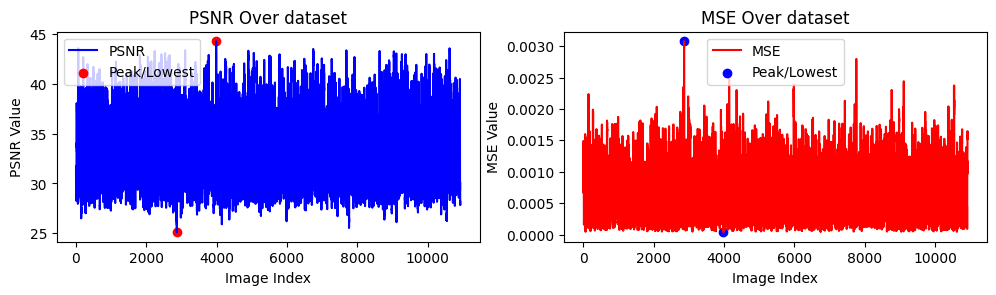

Peak PSNR: 44.26 dB at index 3986
Lowest PSNR: 25.12 dB at index 2867
Peak MSE: 0.00 at index 3986
Lowest MSE: 0.00 at index 2867


In [63]:
def calculate_metrics(original, degraded):
    psnr_value = peak_signal_noise_ratio(original, degraded)
    mse_value = mean_squared_error(original, degraded)
    return psnr_value, mse_value


num_samples = 10930
# Calculate metrics for each pair of images
psnr_values = []
mse_values = []
for i in range(num_samples):
    psnr, mse = calculate_metrics(test_data[i], predictions_test2[i])
    psnr_values.append(psnr)
    mse_values.append(mse)

# Find peak and lowest values and their indices
peak_psnr_value = max(psnr_values)
lowest_psnr_value = min(psnr_values)
peak_psnr_index = psnr_values.index(peak_psnr_value)
lowest_psnr_index = psnr_values.index(lowest_psnr_value)

peak_mse_value = min(mse_values)  # Lower MSE is better
lowest_mse_value = max(mse_values)
peak_mse_index = mse_values.index(peak_mse_value)
lowest_mse_index = mse_values.index(lowest_mse_value)

# Plotting
plt.figure(figsize=(12, 6))

# PSNR Plot
plt.subplot(2, 2, 1)
plt.plot(psnr_values, label='PSNR', color='blue')
plt.scatter([peak_psnr_index, lowest_psnr_index], [peak_psnr_value, lowest_psnr_value], color='red', label='Peak/Lowest')
plt.title('PSNR Over dataset')
plt.xlabel('Image Index')
plt.ylabel('PSNR Value')
plt.legend()

# MSE Plot
plt.subplot(2, 2, 2)
plt.plot(mse_values, label='MSE', color='red')
plt.scatter([peak_mse_index, lowest_mse_index], [peak_mse_value, lowest_mse_value], color='blue', label='Peak/Lowest')
plt.title('MSE Over dataset')
plt.xlabel('Image Index')
plt.ylabel('MSE Value')
plt.legend()

plt.show()

# Print peak and lowest values and their indices
print(f"Peak PSNR: {peak_psnr_value:.2f} dB at index {peak_psnr_index}")
print(f"Lowest PSNR: {lowest_psnr_value:.2f} dB at index {lowest_psnr_index}")
print(f"Peak MSE: {peak_mse_value:.2f} at index {peak_mse_index}")
print(f"Lowest MSE: {lowest_mse_value:.2f} at index {lowest_mse_index}")
